# Crisis Connect — Phase 3b: NLP Text Classifier (TF-IDF + MLP)
**CSC-233 Artificial Intelligence Lab | Spring 2026**
**Component owner: Ezzah Ali**

### Classes: earthquake | flood | fire | traffic_incident

**What this notebook does:**
1. Loads TF-IDF vectors from Phase 3a (Imman's output)
2. Trains an MLP classifier on the text vectors
3. Evaluates on val and test sets
4. Saves the trained MLP model to Drive
5. Tests inference on new text input

**Requires:** crisis connect_phase3a/ folder on Drive from Phase 3a

## Cell 1 — Install and import

In [1]:
!pip install scikit-learn matplotlib seaborn -q

import os
import numpy as np
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print('All packages imported.')

All packages imported.


## Cell 2 — Mount Drive and load Phase 3a files

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import scipy.sparse as sp
import joblib

PHASE3A_DIR = '/content/drive/MyDrive/crisis connect_phase3a'
OUTPUT_DIR  = '/content/drive/MyDrive/crisis connect_phase3b'
CLASSES     = ['earthquake', 'flood', 'fire', 'traffic_incident']

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load TF-IDF matrices
X_train = sp.load_npz(os.path.join(PHASE3A_DIR, 'X_train.npz'))
X_val   = sp.load_npz(os.path.join(PHASE3A_DIR, 'X_val.npz'))
X_test  = sp.load_npz(os.path.join(PHASE3A_DIR, 'X_test.npz'))

# Load labels
y_train = np.load(os.path.join(PHASE3A_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(PHASE3A_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(PHASE3A_DIR, 'y_test.npy'))

# Load vectorizer and label encoder
vectorizer = joblib.load(os.path.join(PHASE3A_DIR, 'tfidf_vectorizer.pkl'))
le         = joblib.load(os.path.join(PHASE3A_DIR, 'label_encoder.pkl'))

print('Files loaded successfully from Phase 3a.')
print()
print(f'X_train shape : {X_train.shape}')
print(f'X_val shape   : {X_val.shape}')
print(f'X_test shape  : {X_test.shape}')
print()
print(f'y_train samples : {len(y_train)}')
print(f'y_val samples   : {len(y_val)}')
print(f'y_test samples  : {len(y_test)}')
print()
print(f'Classes : {le.classes_}')

Mounted at /content/drive
Files loaded successfully from Phase 3a.

X_train shape : (86, 1208)
X_val shape   : (19, 1208)
X_test shape  : (19, 1208)

y_train samples : 86
y_val samples   : 19
y_test samples  : 19

Classes : ['earthquake' 'fire' 'flood' 'traffic_incident']


## Cell 3 — Train MLP classifier

In [3]:
from sklearn.neural_network import MLPClassifier
import time

# MLP architecture:
# Input: 3000 TF-IDF features
# Hidden layer 1: 512 neurons
# Hidden layer 2: 256 neurons
# Output: 4 classes

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation='relu',
    solver='adam',
    alpha=0.001,           # L2 regularisation
    batch_size=32,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

print('Training MLP classifier...')
print('Architecture: 3000 -> 512 -> 256 -> 4')
print()

start = time.time()
mlp.fit(X_train, y_train)
elapsed = time.time() - start

print()
print(f'Training complete in {elapsed:.1f} seconds.')
print(f'Epochs trained    : {mlp.n_iter_}')
print(f'Final train loss  : {mlp.loss_:.4f}')

Training MLP classifier...
Architecture: 3000 -> 512 -> 256 -> 4

Iteration 1, loss = 1.40941998
Validation score: 0.222222
Iteration 2, loss = 1.32402056
Validation score: 0.444444
Iteration 3, loss = 1.24323260
Validation score: 0.444444
Iteration 4, loss = 1.15029032
Validation score: 0.444444
Iteration 5, loss = 1.03117940
Validation score: 0.555556
Iteration 6, loss = 0.88811098
Validation score: 0.666667
Iteration 7, loss = 0.72440153
Validation score: 0.777778
Iteration 8, loss = 0.55263010
Validation score: 0.777778
Iteration 9, loss = 0.38784214
Validation score: 0.777778
Iteration 10, loss = 0.24836040
Validation score: 0.777778
Iteration 11, loss = 0.14939247
Validation score: 0.888889
Iteration 12, loss = 0.08680691
Validation score: 0.888889
Iteration 13, loss = 0.05286847
Validation score: 0.888889
Iteration 14, loss = 0.03542629
Validation score: 0.888889
Iteration 15, loss = 0.02617014
Validation score: 0.888889
Iteration 16, loss = 0.02151114
Validation score: 0.888889

## Cell 4 — Evaluate on validation set

In [4]:
from sklearn.metrics import accuracy_score, classification_report

val_preds = mlp.predict(X_val)
val_acc   = accuracy_score(y_val, val_preds)

print(f'Validation Accuracy: {val_acc:.4f}  ({val_acc*100:.2f}%)')
print()
print('Validation Classification Report:')
print('=' * 60)
print(classification_report(
    y_val, val_preds,
    target_names=le.classes_,
    digits=4
))

Validation Accuracy: 0.7368  (73.68%)

Validation Classification Report:
                  precision    recall  f1-score   support

      earthquake     0.8000    0.8000    0.8000         5
            fire     0.6667    1.0000    0.8000         4
           flood     0.5000    0.4000    0.4444         5
traffic_incident     1.0000    0.8000    0.8889         5

        accuracy                         0.7368        19
       macro avg     0.7417    0.7500    0.7333        19
    weighted avg     0.7456    0.7368    0.7298        19



## Cell 5 — Evaluate on test set

In [5]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

test_preds = mlp.predict(X_test)
test_probs = mlp.predict_proba(X_test)
test_acc   = accuracy_score(y_test, test_preds)

print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print()
print('Test Classification Report:')
print('=' * 60)
print(classification_report(
    y_test, test_preds,
    target_names=le.classes_,
    digits=4
))

Test Accuracy: 0.8947  (89.47%)

Test Classification Report:
                  precision    recall  f1-score   support

      earthquake     0.8000    0.8000    0.8000         5
            fire     1.0000    0.8000    0.8889         5
           flood     0.8333    1.0000    0.9091         5
traffic_incident     1.0000    1.0000    1.0000         4

        accuracy                         0.8947        19
       macro avg     0.9083    0.9000    0.8995        19
    weighted avg     0.9035    0.8947    0.8942        19



## Cell 6 — Plot confusion matrix

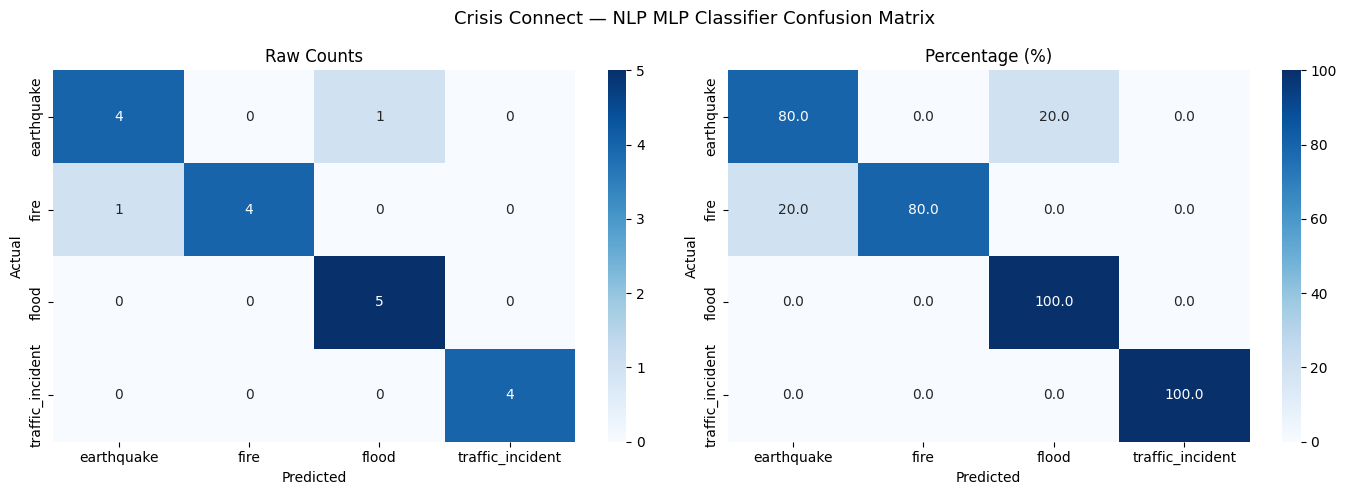

Confusion matrix saved: /content/drive/MyDrive/crisis connect_phase3b/confusion_matrix.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

cm     = confusion_matrix(y_test, test_preds)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Crisis Connect — NLP MLP Classifier Confusion Matrix', fontsize=13)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Percentage (%)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=100)
plt.show()
print(f'Confusion matrix saved: {cm_path}')

## Cell 7 — Plot training loss curve

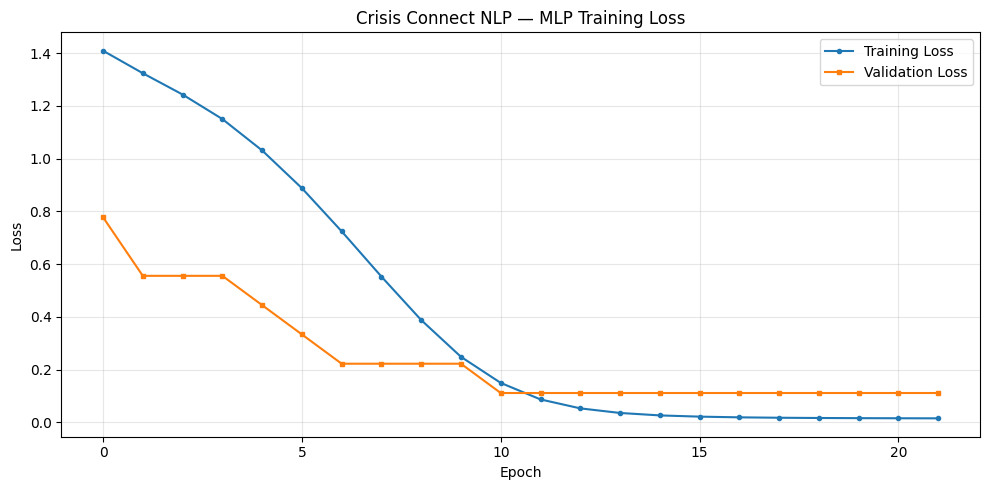

Loss curve saved: /content/drive/MyDrive/crisis connect_phase3b/training_loss.png


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, label='Training Loss', marker='o', markersize=3)
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    plt.plot(
        [1 - s for s in mlp.validation_scores_],
        label='Validation Loss', marker='s', markersize=3
    )
plt.title('Crisis Connect NLP — MLP Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
loss_path = os.path.join(OUTPUT_DIR, 'training_loss.png')
plt.savefig(loss_path, dpi=100)
plt.show()
print(f'Loss curve saved: {loss_path}')

## Cell 8 — Save model to Drive

In [8]:
import joblib, os

model_path = os.path.join(OUTPUT_DIR, 'mlp_classifier.pkl')
joblib.dump(mlp, model_path)

print(f'MLP model saved: {model_path}')
print()
print('Files saved to crisis connect_phase3b/ on Drive:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f'  {f:<35} {size:.1f} KB')

MLP model saved: /content/drive/MyDrive/crisis connect_phase3b/mlp_classifier.pkl

Files saved to crisis connect_phase3b/ on Drive:
  confusion_matrix.png                44.1 KB
  mlp_classifier.pkl                  17618.5 KB
  training_loss.png                   37.4 KB


## Cell 9 — Test inference on new text input

In [9]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
KEEP_WORDS = {'no', 'not', 'very', 'too', 'above', 'below', 'near', 'under', 'over'}
stop_words = stop_words - KEEP_WORDS

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

def predict_text(text):
    cleaned = clean_text(text)
    vec     = vectorizer.transform([cleaned])
    pred    = mlp.predict(vec)[0]
    probs   = mlp.predict_proba(vec)[0]
    label   = le.inverse_transform([pred])[0]
    conf    = probs[pred]
    print(f'Input     : "{text}"')
    print(f'Cleaned   : "{cleaned}"')
    print(f'Prediction: {label}')
    print(f'Confidence: {conf:.4f}')
    print('All class probabilities:')
    for i, cls in enumerate(le.classes_):
        bar = '█' * int(probs[i] * 20)
        print(f'  {cls:<22} {probs[i]:.4f}  {bar}')
    print()
    return label, conf

# Test with sample inputs
print('=' * 55)
print('INFERENCE TESTS')
print('=' * 55)
print()

test_inputs = [
    'Water rising fast on main road bridge submerged',
    'Strong earthquake shaking walls cracked people running',
    'Large fire spreading market shops burning black smoke',
    'Truck overturned highway blocking all lanes accident'
]

for text in test_inputs:
    predict_text(text)
    print('-' * 55)
    print()

INFERENCE TESTS

Input     : "Water rising fast on main road bridge submerged"
Cleaned   : "water rising fast main road bridge submerged"
Prediction: flood
Confidence: 0.6894
All class probabilities:
  earthquake             0.1676  ███
  fire                   0.0710  █
  flood                  0.6894  █████████████
  traffic_incident       0.0720  █

-------------------------------------------------------

Input     : "Strong earthquake shaking walls cracked people running"
Cleaned   : "strong earthquake shaking walls cracked people running"
Prediction: earthquake
Confidence: 0.8857
All class probabilities:
  earthquake             0.8857  █████████████████
  fire                   0.0383  
  flood                  0.0448  
  traffic_incident       0.0311  

-------------------------------------------------------

Input     : "Large fire spreading market shops burning black smoke"
Cleaned   : "large fire spreading market shops burning black smoke"
Prediction: fire
Confidence: 0.9659


## Cell 10 — Summary

In [10]:
import os

print('=' * 55)
print('  Phase 3b Complete')
print('=' * 55)
print()
print(f'Test Accuracy : {test_acc*100:.2f}%')
print()
print('Files saved to: crisis connect_phase3b/')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f'  {f:<35} {size:.1f} KB')
print()
print('(Phase 4 Fusion Layer):')
print('  crisis connect_phase3b/mlp_classifier.pkl')
print('  crisis connect_phase3a/tfidf_vectorizer.pkl')
print('  crisis connect_phase3a/label_encoder.pkl')
print('  crisis connect_model/resnet50_crisis_connect.pth')

  Phase 3b Complete

Test Accuracy : 89.47%

Files saved to: crisis connect_phase3b/
  confusion_matrix.png                44.1 KB
  mlp_classifier.pkl                  17618.5 KB
  training_loss.png                   37.4 KB

(Phase 4 Fusion Layer):
  crisis connect_phase3b/mlp_classifier.pkl
  crisis connect_phase3a/tfidf_vectorizer.pkl
  crisis connect_phase3a/label_encoder.pkl
  crisis connect_model/resnet50_crisis_connect.pth
